In [1]:
# Installazione
!pip install timm

In [2]:
! wget https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz

--2025-12-03 16:13:30--  https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 16.12.19.22, 3.5.204.12
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|16.12.19.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63234337 (60M) [application/x-gzip]
Saving to: ‘progetto-finale-flowes.tar.gz’

progetto-finale-flo 100%[===================>]  60.30M  15.5MB/s    in 3.9s    

2025-12-03 16:13:34 (15.5 MB/s) - ‘progetto-finale-flowes.tar.gz’ saved [63234337/63234337]



In [3]:
! tar -xzf progetto-finale-flowes.tar.gz

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown 

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchsummary import summary
import timm
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [5]:
# Creo delle trasformazioni per il validazione ed il test set
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Ridimensiona l'immagine a 224x224
    transforms.ToTensor(),          # Converte l'immagine in un tensore PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizza il tensore usando i valori standard di ImageNet
])

# Per il dataset di train aggiungo delle modifiche delle immagini per migliorare la diversità dei dati (data augmentation)
data_augment = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Applica rotazione casuale
    transforms.RandomHorizontalFlip(p=0.5), # Applica flip orizzontale casuale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
# Le immagini devono essere organizzate in sottocartelle per classe come richiesto dalla classe ImageFolder che inferisce automaticamente le etichette (labels) delle classi dai nomi delle sottocartelle. Creo i dataset utilizzando ImageFolder e applico le trasformazioni

def is_valid_file(path):
    return not os.path.basename(path).startswith('._') # Ignora i file nascosti di macOS (che iniziano con '._')

trainset = ImageFolder(root='/content/progetto-finale-flowes/train', transform=data_augment, is_valid_file=is_valid_file)
valset = ImageFolder(root='/content/progetto-finale-flowes/valid', transform=data_transforms, is_valid_file=is_valid_file)
testset = ImageFolder(root='/content/progetto-finale-flowes/test', transform=data_transforms, is_valid_file=is_valid_file)

# Stampa il numero totale di immagini nel dataset
print(f"Numero totale di immagini nel dataset di train: {len(trainset)}")
print(f"Numero totale di immagini nel dataset di validation: {len(valset)}")
print(f"Numero totale di immagini nel dataset di test: {len(testset)}")
print("---------------------------------------------------------")

def distribuzione_classe(dataset):
  targets = np.array(dataset.targets)
  classes, counts = np.unique(targets, return_counts=True)
  print(f"Distribuzione classi: {counts}")

# Stampa le classi rilevate da ImageFolder ed il numero
print(f"Classi rilevate: {testset.classes}")
print("---------------------------------------------------------")
print(f"Numero classi train set: {len(trainset.classes)}")
distribuzione_classe(trainset)
print("---------------------------------------------------------")
print(f"Numero classi test set: {len(testset.classes)}")
distribuzione_classe(testset)
print("---------------------------------------------------------")
print(f"Numero classi val set: {len(valset.classes)}")
distribuzione_classe(valset)


Numero totale di immagini nel dataset di train: 1275
Numero totale di immagini nel dataset di validation: 364
Numero totale di immagini nel dataset di test: 182
---------------------------------------------------------
Classi rilevate: ['daisy', 'dandelion']
---------------------------------------------------------
Numero classi train set: 2
Distribuzione classi: [529 746]
---------------------------------------------------------
Numero classi test set: 2
Distribuzione classi: [ 77 105]
---------------------------------------------------------
Numero classi val set: 2
Distribuzione classi: [163 201]


In [7]:
#stampo le dimensioni del tensore che rappresenta l'immagine 300 del trainset
trainset[0][0].shape

torch.Size([3, 224, 224])

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [9]:
# Creo un modello pre-addestrato
model = timm.create_model(
    'lcnet_075.ra2_in1k',   # nome del modello
    pretrained=True,      # scarica i pesi da ImageNet
    num_classes=2        # sostituisce automaticamente l'ultimo layer
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/9.48M [00:00<?, ?B/s]

In [10]:
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
          Identity-2         [-1, 16, 112, 112]               0
         Hardswish-3         [-1, 16, 112, 112]               0
    BatchNormAct2d-4         [-1, 16, 112, 112]              32
            Conv2d-5         [-1, 16, 112, 112]             144
          Identity-6         [-1, 16, 112, 112]               0
         Hardswish-7         [-1, 16, 112, 112]               0
    BatchNormAct2d-8         [-1, 16, 112, 112]              32
          Identity-9         [-1, 16, 112, 112]               0
         Identity-10         [-1, 16, 112, 112]               0
           Conv2d-11         [-1, 24, 112, 112]             384
         Identity-12         [-1, 24, 112, 112]               0
        Hardswish-13         [-1, 24, 112, 112]               0
   BatchNormAct2d-14         [-1, 24, 1

*   Pesi (Weights): Sono i valori che moltiplicano gli input di un neurone. Sono fondamentali per apprendere i pattern nei dati.
*   Bias: Sono valori aggiunti agli output di un neurone, permettendo al modello di adattarsi meglio a determinati pattern anche quando gli input sono zero.

Quindi, quando summary() riporta "Total params: 1,079,850", significa che il tuo modello ha un totale di 1.079.850 valori numerici (tra pesi e bias) che possono essere appresi o aggiustati durante il processo di addestramento. Questi sono tutti i numeri che il modello deve "imparare" per eseguire correttamente il suo compito (nel tuo caso, classificare le immagini di fiori).



In [11]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv_stem.weight True
bn1.weight True
bn1.bias True
blocks.0.0.conv_dw.weight True
blocks.0.0.bn1.weight True
blocks.0.0.bn1.bias True
blocks.0.0.conv_pw.weight True
blocks.0.0.bn2.weight True
blocks.0.0.bn2.bias True
blocks.1.0.conv_dw.weight True
blocks.1.0.bn1.weight True
blocks.1.0.bn1.bias True
blocks.1.0.conv_pw.weight True
blocks.1.0.bn2.weight True
blocks.1.0.bn2.bias True
blocks.1.1.conv_dw.weight True
blocks.1.1.bn1.weight True
blocks.1.1.bn1.bias True
blocks.1.1.conv_pw.weight True
blocks.1.1.bn2.weight True
blocks.1.1.bn2.bias True
blocks.2.0.conv_dw.weight True
blocks.2.0.bn1.weight True
blocks.2.0.bn1.bias True
blocks.2.0.conv_pw.weight True
blocks.2.0.bn2.weight True
blocks.2.0.bn2.bias True
blocks.2.1.conv_dw.weight True
blocks.2.1.bn1.weight True
blocks.2.1.bn1.bias True
blocks.2.1.conv_pw.weight True
blocks.2.1.bn2.weight True
blocks.2.1.bn2.bias True
blocks.3.0.conv_dw.weight True
blocks.3.0.bn1.weight True
blocks.3.0.bn1.bias True
blocks.3.0.conv_pw.weight True
bloc

Il metodo named_parameters() restituisce un iteratore che genera coppie di (nome, parametro) per tutti i parametri del modello. Ogni elemento dell'iteratore è:
*   nome (stringa): Una stringa che descrive gerarchicamente la posizione del parametro all'interno del modello. -> classifier.bias indica i bias del modulo classifier
*   parametro (tensore torch.nn.Parameter): Il tensore PyTorch effettivo che contiene i valori numerici (pesi o bias) del parametro, e che traccia se richiede il calcolo del gradiente (requires_grad).

L'output elenca ogni parametro con il suo nome all'interno dell'architettura del modello, e un valore booleano (True o False) per param.requires_grad.

*   name: contiene i nomi che pytorch usa per identificare e accedere ai pesi (.weight) e ai bias (.bias) di ogni modulo (layer) della rete. Questi nomi sono cruciali quando si vuole ispezionare, congelare (param.requires_grad = False) o manipolare specifici parametri del modello.
  1.   'bn1.weight' tensore contenente i pesi del primo layer di batch normalization
  2.   'classifier.bias' contiene i bias del layer di classificazione finale
  3. 'blocks.0.0.conv_dw.weight' -> blocks indica che stiamo entrando in una sequenza di blocchi (spesso strutture ripetute). 0.0 indica l'indice del blocco e del sotto-blocco all'interno della sequenza (0 sarebbe il primo blocco, 0 il primo sottoblocco al suo interno). conv_dw (depthwise convolution) e conv_pw (pointwise convolution) si riferiscono a tipi specifici di operazioni convoluzionali all'interno di questi blocchi. weight o bias indicano se è il peso o il bias di quella specifica operazione convoluzionale

*   param.requires_grad: Questo valore booleano ti dice se il parametro è impostato per essere aggiornato durante il passo di backpropagation dell'addestramento. Se True, il gradiente del parametro verrà calcolato e utilizzato per aggiornarne il valore. Se False, il parametro è congelato (il suo valore non cambierà durante l'addestramento), il che è comune nel transfer learning quando si desidera mantenere i layer pre-addestrati fissi.

In [12]:
model.bn1.weight

Parameter containing:
tensor([ 1.1377,  4.7133,  3.8672,  0.5124,  1.6124,  1.3876, -0.4071,  0.6600,
         0.2820,  0.1590,  0.6282, -0.5004,  6.6278,  0.0500,  0.2739,  0.5541],
       device='cuda:0', requires_grad=True)

In [14]:
model.bn1.weight.__len__()

16

In [13]:
model.bn1.bias

Parameter containing:
tensor([ 3.0375,  1.2659,  2.6174,  3.0783, -0.5866,  2.7694,  1.6219,  2.9234,
         2.8039,  0.4248,  2.6595,  2.3460,  7.9648,  0.1046,  2.5157,  2.6617],
       device='cuda:0', requires_grad=True)

In [15]:
model.bn1.bias.__len__()

16

16 + 16 = 32, esattamente i parametri calcolati nel primo layer di batch normalization ' BatchNormAct2d-4 '

In [57]:
#Creo i DataLoader per i set di addestramento, validazione e test per poter gestire i dati in batch durante l'addestramento, la validazione e la valutazione finale.
from torch.utils.data import DataLoader

batch_size = 64

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Definisco funzione per ciclo di addestramento:

1-Iterare attraverso i batch di dati dal trainloader.

2- Per ogni batch, eseguire un forward pass con il modello per ottenere le predizioni.

3-Calcolare la funzione di perdita confrontando le predizioni con le etichette vere.

4-Eseguire una backward pass per calcolare i gradienti.

5-Aggiornare i pesi del modello utilizzando l'ottimizzatore.

6-Monitorare la perdita e l'accuratezza sul set di addestramento.

Stessa cosa per il ciclo di validazione ma senza il calcolo dei gradienti

In [58]:
def train_model(model, trainloader, valloader, criterion, optimizer, epochs, patience, device, model_save_path):
  # Liste per memorizzare la perdita e l'accuratezza durante l'addestramento e la validazione
  train_loss_history = []
  train_acc_history = []
  val_loss_history = []
  val_acc_history = []
  train_f1_history = []
  val_f1_history = []

  # parametri per Early Stopping
  best_val_loss = float('inf') # Inizializza il valore della migliore loss di validazione a infinito
  epochs_no_improve = 0 # Contatore per le epoche senza miglioramento

  for epoch in range(epochs):  # ripeti il training per 100 epoche
      model.train() # Imposta il modello in modalità addestramento
      running_loss = 0.0 # inizializzo le variabili per tenere traccia della perdita totale (running_loss), del numero di predizioni corrette (correct_train) e del numero totale di immagini elaborate (total_train) per l'epoca corrente.
      correct_train = 0
      total_train = 0
      all_train_labels = []
      all_train_preds = []

      for i, data in enumerate(trainloader, 0):
          # dal Dataloader estrai un batch di immagini ed etichette (input, labels) e passalo su GPU
          inputs, labels = data
          inputs, labels = inputs.to(device), labels.to(device) #inputs=[batch_size, 2048, 1, 1], labels=[batch_size, 14]=[64,14]

          # azzera i gradienti accumulati dai passi precedenti
          optimizer.zero_grad()

          # forward pass passando le immagini di input attraverso il modello per ottenere le predizioni
          outputs = model(inputs) #[64,14]
          loss = criterion(outputs, labels)

          # backward pass per calcolare i gradienti della perdita rispetto a tutti i parametri addestrabili del modello e ottimizzazione per aggiornare i pesi
          loss.backward()
          optimizer.step()

          # aggiorna le statistiche per ogni batch
          running_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          total_train += labels.size(0)
          correct_train += (predicted == labels).sum().item()
          all_train_labels.extend(labels.cpu().numpy())
          all_train_preds.extend(predicted.cpu().numpy())

      # calcolo delle metriche di epoca
      epoch_train_loss = running_loss / len(trainloader)
      epoch_train_acc = 100 * correct_train / total_train
      epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
      # memorizzazione: aggiunge la perdita e l'accuratezza dell'epoca corrente alle rispettive liste di storico
      train_loss_history.append(epoch_train_loss)
      train_acc_history.append(epoch_train_acc)
      train_f1_history.append(epoch_train_f1)

      print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Train F1: {epoch_train_f1:.4f}')

      # Fase di validazione
      model.eval()  # Imposta il modello in modalità valutazione
      running_val_loss = 0.0
      correct_val = 0
      total_val = 0
      all_val_labels = []
      all_val_preds = []

      with torch.no_grad():  # disattiva il calcolo dei gradienti in fase di validazione
          for data in valloader:
              inputs, labels = data
              inputs, labels = inputs.to(device), labels.to(device)

              outputs = model(inputs)
              loss = criterion(outputs, labels)
              running_val_loss += loss.item()

              _, predicted = torch.max(outputs.data, 1)
              total_val += labels.size(0)
              correct_val += (predicted == labels).sum().item()
              all_val_labels.extend(labels.cpu().numpy())
              all_val_preds.extend(predicted.cpu().numpy())

      epoch_val_loss = running_val_loss / len(valloader)
      epoch_val_acc = 100 * correct_val / total_val
      epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
      val_loss_history.append(epoch_val_loss)
      val_acc_history.append(epoch_val_acc)
      val_f1_history.append(epoch_val_f1)

      print(f'Epoch {epoch + 1}/{epochs}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%, Val F1: {epoch_val_f1:.4f}')

      # Early Stopping check
      if epoch_val_loss < best_val_loss:
          best_val_loss = epoch_val_loss
          epochs_no_improve = 0
          torch.save(model.state_dict(), model_save_path) #salvo il modello qui se questa è la migliore performance finora
          print(f"Salvo il miglior modello dentro {model_save_path}")
      else:
          epochs_no_improve += 1

      if epochs_no_improve == patience:
          print(f'Early stopping')
          break # esci dal ciclo di addestramento

  print('Addestramento completato')
  return train_loss_history, train_acc_history, val_loss_history, val_acc_history, train_f1_history, val_f1_history

FASE A - sblocco solo il classificatore finale


In [59]:
#congelo i layer preaddestrati
for param in model.parameters():
    param.requires_grad = False

# sblocco solo la testa
for param in model.classifier.parameters():
    param.requires_grad = True

In [60]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv_stem.weight False
bn1.weight False
bn1.bias False
blocks.0.0.conv_dw.weight False
blocks.0.0.bn1.weight False
blocks.0.0.bn1.bias False
blocks.0.0.conv_pw.weight False
blocks.0.0.bn2.weight False
blocks.0.0.bn2.bias False
blocks.1.0.conv_dw.weight False
blocks.1.0.bn1.weight False
blocks.1.0.bn1.bias False
blocks.1.0.conv_pw.weight False
blocks.1.0.bn2.weight False
blocks.1.0.bn2.bias False
blocks.1.1.conv_dw.weight False
blocks.1.1.bn1.weight False
blocks.1.1.bn1.bias False
blocks.1.1.conv_pw.weight False
blocks.1.1.bn2.weight False
blocks.1.1.bn2.bias False
blocks.2.0.conv_dw.weight False
blocks.2.0.bn1.weight False
blocks.2.0.bn1.bias False
blocks.2.0.conv_pw.weight False
blocks.2.0.bn2.weight False
blocks.2.0.bn2.bias False
blocks.2.1.conv_dw.weight False
blocks.2.1.bn1.weight False
blocks.2.1.bn1.bias False
blocks.2.1.conv_pw.weight False
blocks.2.1.bn2.weight False
blocks.2.1.bn2.bias False
blocks.3.0.conv_dw.weight False
blocks.3.0.bn1.weight False
blocks.3.0.bn1.bias False

In [15]:
criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(filter(lambda x: x.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4) #sto passando solo i parametri del modello modificato per l'ottimizzazione. Aggiungo weight_decay per la regolarizzazione L2
epochs_1 = 10
patience_1 = 5 #epoche dopo le quali il training si ferma se non c'è miglioramento
model_save_path_1 = 'best_model_1.pth'

# Addestramento per la fase 1
train_loss_history_1, train_acc_history_1, val_loss_history_1, val_acc_history_1, train_f1_history_1, val_f1_history_1 = \
    train_model(model, trainloader, valloader, criterion_1, optimizer_1, epochs_1, patience_1, device, model_save_path_1)

Epoch 1/10, Train Loss: 2.9739, Train Acc: 49.33%, Train F1: 0.4903
Epoch 1/10, Val Loss: 1.9182, Val Acc: 61.81%, Val F1: 0.6176
Salvo il miglior modello dentro best_model_1.pth
Epoch 2/10, Train Loss: 2.2842, Train Acc: 57.41%, Train F1: 0.5676
Epoch 2/10, Val Loss: 1.6145, Val Acc: 66.48%, Val F1: 0.6622
Salvo il miglior modello dentro best_model_1.pth
Epoch 3/10, Train Loss: 1.8341, Train Acc: 64.86%, Train F1: 0.6412
Epoch 3/10, Val Loss: 1.3898, Val Acc: 70.33%, Val F1: 0.7024
Salvo il miglior modello dentro best_model_1.pth
Epoch 4/10, Train Loss: 1.5894, Train Acc: 68.47%, Train F1: 0.6767
Epoch 4/10, Val Loss: 1.2058, Val Acc: 73.63%, Val F1: 0.7358
Salvo il miglior modello dentro best_model_1.pth
Epoch 5/10, Train Loss: 1.3949, Train Acc: 72.24%, Train F1: 0.7154
Epoch 5/10, Val Loss: 1.1056, Val Acc: 74.73%, Val F1: 0.7470
Salvo il miglior modello dentro best_model_1.pth
Epoch 6/10, Train Loss: 1.2795, Train Acc: 74.35%, Train F1: 0.7378
Epoch 6/10, Val Loss: 0.9869, Val Acc

In [16]:
#Avevo già salvato i pesi del modello migliore trovato nella fase 1. Adesso creo un modello e ricarico questi pesi

# creo l'architettura identica
best_model_1 = timm.create_model('lcnet_075.ra2_in1k', pretrained=True, num_classes=2).to(device)

# carico i pesi migliori
best_model_1.load_state_dict(torch.load('best_model_1.pth'))

<All keys matched successfully>

In [17]:
# Fase di test 1
best_model_1.eval()  # Imposta il modello in modalità valutazione
#Vengono inizializzate le variabili per tenere traccia del numero di predizioni corrette (correct_test), del numero totale di immagini nel set di test (total_test). Vengono anche create due liste vuote, all_predicted e all_labels, per memorizzare tutte le predizioni del modello e le etichette vere rispettivamente (serviranno in seguito per calcolare metriche più dettagliate come la matrice di confusione).
correct_test = 0
total_test = 0
test_loss = 0.0
predizioni = [] #salvo predizioni ed etichette per poi generare la matrice di confusione
etichette = []

with torch.no_grad():  # Non calcolare i gradienti in fase di test
    for data in testloader:
        images, labels = data  #Estrae le immagini e le etichette dal batch.
        images, labels = images.to(device), labels.to(device)

        #forward pass
        outputs = best_model_1(images)

        #calcola la loss
        loss = criterion_1(outputs, labels)
        test_loss += loss.item()

        #Trova l'indice della classe con la probabilità più alta per ogni immagine nel batch. predicted conterrà le predizioni del modello per il batch corrente.
        _, predicted = torch.max(outputs.data, 1)

        #Aggiorna total_test con il numero di immagini nel batch corrente e correct_test con il numero di predizioni corrette in quel batch.
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        #Memorizzazione delle predizioni e etichette: aggiunge le predizioni e le etichette vere del batch corrente alle liste predizioni[] ed etichette[]. .cpu().numpy() converte i tensori PyTorch in array NumPy sulla CPU per poterli estendere alle liste Python create sopra
        predizioni.extend(predicted.cpu().numpy())
        etichette.extend(labels.cpu().numpy())

#Calcolo dell'accuratezza finale: numero totale di predizioni corrette (correct_test) diviso per il numero totale di immagini nel set di test (total_test)
test_acc = 100 * correct_test / total_test
f1 = f1_score(etichette, predizioni, average='macro')
print(f'Accuracy test set: {test_acc:.2f}%')
print(f'F1 test set: {f1:.2f}')

Accuracy test set: 81.32%
F1 test set: 0.81


FASE B - fine-tuning del backbone


In [18]:
# creo l'architettura identica
best_model_2 = timm.create_model('lcnet_075.ra2_in1k', pretrained=True, num_classes=2).to(device)

# carico i pesi migliori
best_model_2.load_state_dict(torch.load('best_model_1.pth'))

<All keys matched successfully>

In [19]:
#congelo i layer preaddestrati
for param in best_model_2.parameters():
    param.requires_grad = False

# Unfreeze del penultimo layer (blocco 5)
for param in best_model_2.blocks[5].parameters():
    param.requires_grad = True

# Unfreeze dell'ultimo layer di classificazione
for param in best_model_2.classifier.parameters():
    param.requires_grad = True

In [20]:
criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(filter(lambda x: x.requires_grad, best_model_2.parameters()), lr=0.001, weight_decay=1e-4)
epochs_2 = 10
patience_2 = 5
model_save_path_2 = 'best_model_2.pth'

# Addestramento per la fase 2
train_loss_history_2, train_acc_history_2, val_loss_history_2, val_acc_history_2, train_f1_history_2, val_f1_history_2 = \
    train_model(best_model_2, trainloader, valloader, criterion_2, optimizer_2, epochs_2, patience_2, device, model_save_path_2)

Epoch 1/10, Train Loss: 0.6207, Train Acc: 87.14%, Train F1: 0.8676
Epoch 1/10, Val Loss: 0.3951, Val Acc: 91.21%, Val F1: 0.9109
Salvo il miglior modello dentro best_model_2.pth
Epoch 2/10, Train Loss: 0.2017, Train Acc: 94.98%, Train F1: 0.9483
Epoch 2/10, Val Loss: 0.3264, Val Acc: 92.86%, Val F1: 0.9282
Salvo il miglior modello dentro best_model_2.pth
Epoch 3/10, Train Loss: 0.0919, Train Acc: 97.41%, Train F1: 0.9733
Epoch 3/10, Val Loss: 0.3174, Val Acc: 93.68%, Val F1: 0.9364
Salvo il miglior modello dentro best_model_2.pth
Epoch 4/10, Train Loss: 0.0786, Train Acc: 97.73%, Train F1: 0.9766
Epoch 4/10, Val Loss: 0.2921, Val Acc: 93.13%, Val F1: 0.9307
Salvo il miglior modello dentro best_model_2.pth
Epoch 5/10, Train Loss: 0.0621, Train Acc: 98.12%, Train F1: 0.9806
Epoch 5/10, Val Loss: 0.2996, Val Acc: 93.13%, Val F1: 0.9309
Epoch 6/10, Train Loss: 0.0518, Train Acc: 98.43%, Train F1: 0.9838
Epoch 6/10, Val Loss: 0.2654, Val Acc: 93.41%, Val F1: 0.9336
Salvo il miglior modello

In [21]:
# Fase di test 2
best_model_2.eval()

correct_test = 0
total_test = 0
test_loss = 0.0
predizioni = []
etichette = []

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        #forward pass
        outputs = best_model_2(images)

        #calcola la loss
        loss = criterion_2(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        #Memorizzazione delle predizioni e etichette: aggiunge le predizioni e le etichette vere del batch corrente alle liste predizioni[] ed etichette[]. .cpu().numpy() converte i tensori PyTorch in array NumPy sulla CPU per poterli estendere alle liste Python create sopra
        predizioni.extend(predicted.cpu().numpy())
        etichette.extend(labels.cpu().numpy())

test_acc = 100 * correct_test / total_test
f1 = f1_score(etichette, predizioni, average='macro')
print(f'Accuracy test set: {test_acc:.2f}%')
print(f'F1 test set: {f1:.2f}')

Accuracy test set: 95.60%
F1 test set: 0.95


Grad-cam su un'immagine per interpretabilità

In [22]:
#Prendo una immagine dal testloader, con la sua label.

model.eval()
images, labels = next(iter(testloader)) # prendo un batch dal testloader
img = images[1].unsqueeze(0).to(device)  # prendo la seconda immagine del batch -> shape [1,3,224,224]
label = labels[1].item()

print("Classe reale:", label, testset.classes[label])

Classe reale: 0 daisy


In [23]:
# prendo la classe predetta dal modello

with torch.no_grad():
    outputs = best_model_1(img)
pred_class = outputs.argmax(dim=1).item()
print("Classe predetta:", pred_class, testset.classes[pred_class])

Classe predetta: 0 daisy


In [24]:
# seleziono il layer target e registro gli hook

target_layer = best_model_1.blocks[-1]
activations = {}
gradients = {}

def forward_hook(module, input, output):
    # output: feature map [1, C, H, W]
    activations["value"] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0].detach()

# Registro gli hook
fh = target_layer.register_forward_hook(forward_hook)
bh = target_layer.register_full_backward_hook(backward_hook)


In [25]:
# Forward pass dell'immagine img attraverso il modello e backward sul logit della classe target

img.requires_grad_(True) #significa che PyTorch deve calcolare e memorizzare i gradienti di questo tensore

outputs = best_model_1(img)
cls = outputs.argmax(dim=1).item()  # classe predetta
score = outputs[0, cls]
best_model_1.zero_grad()   #azzera tutti i gradienti accumulati nel modello (usa best_model_1)
score.backward(retain_graph=True)

In [26]:
# Costruzione cam

A = activations['value']    # Recupera le attivazioni catturate dal fwd_hook. [1, C, H, W]
G = gradients['value']      # Recupera i gradienti catturati dal bwd_hook. [1, C, H, W]

# Calcola i pesi specifici per ogni canale eseguendo un Global Average Pooling sui gradienti. Ciò trasforma i gradienti da [1, C, H, W] a [1, C, 1, 1].
weights = G.mean(dim=(2, 3), keepdim=True)

# Moltiplica i pesi per canale con le attivazioni corrispondenti e somma su tutti i canali. Il risultato è una singola mappa di calore 2D con la forma [H, W].
cam = (weights * A).sum(dim=1, keepdim=True)

# Applica ReLU per mantenere solo i contributi positivi alla classe predetta.
cam = F.relu(cam)

# Normalizza la mappa di calore per avere valori tra 0 e 1.
cam -= cam.min()
cam /= (cam.max() + 1e-8)

# Effettua l'interpolazione della mappa di calore alla dimensione dell'immagine originale. L'input 'cam' è in formato [N, C, H, W]
cam = F.interpolate(cam, size=img.shape[-2:], mode='bilinear', align_corners=False)

# Rimuovi le dimensioni del batch e del canale per ottenere una mappa di calore 2D.
cam = cam.squeeze()

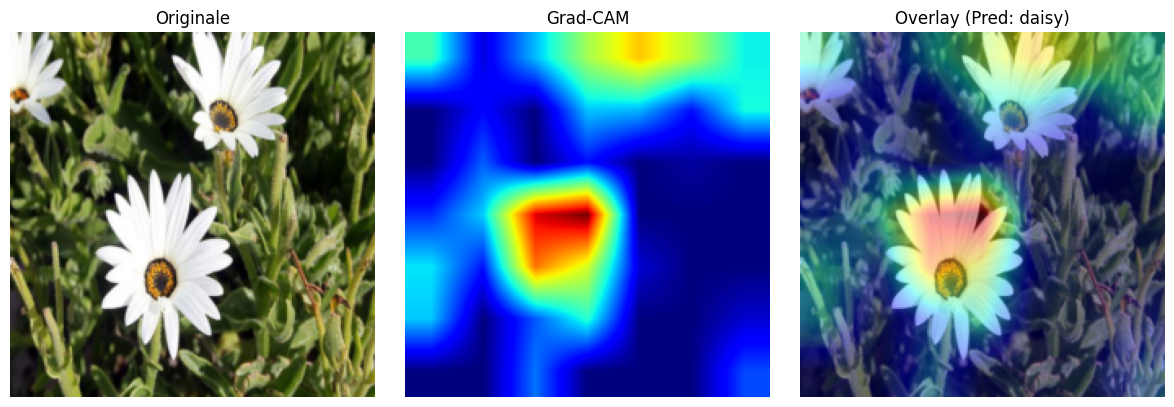

In [31]:
# De-normalizzazione
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

orig = img[0].detach().cpu().numpy().transpose(1,2,0)
orig = std * orig + mean
orig = np.clip(orig, 0, 1)

cam_np = cam.cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(orig)
plt.title("Originale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam_np, cmap='jet')
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(orig)
plt.imshow(cam_np, cmap='jet', alpha=0.4)
plt.title(f"Overlay (Pred: {testset.classes[cls]})")
plt.axis("off")

plt.tight_layout()
plt.show()

# Rimuovo gli hook
fh.remove()
bh.remove()
